In [85]:
import matplotlib.pyplot as plt
import math
from skimage.transform import rotate
from skimage.transform import EuclideanTransform
from skimage.transform import SimilarityTransform
from skimage.transform import matrix_transform
from skimage.transform import warp
from skimage.transform import swirl
from skimage import io, color

from skimage import io, color
from skimage.morphology import binary_closing, binary_opening
from skimage.morphology import disk
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
from skimage.color import label2rgb
import pydicom as dicom
from scipy.stats import norm
from scipy.spatial import distance

from skimage import color
from skimage.util import img_as_ubyte
from skimage.util import img_as_float
from skimage.filters import prewitt
from skimage.filters import threshold_otsu
from skimage.filters import median
import time
import cv2
import numpy as np
from scipy.ndimage import correlate
from skimage import io


import skimage
from skimage.util import img_as_float, img_as_ubyte
import cv2
from skimage import color, io
from matplotlib import pyplot as plt
import numpy as np
from skimage.filters import threshold_otsu
from skimage.color import rgb2hsv

from skimage import io, color, morphology
from skimage.util import img_as_float, img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.filters import threshold_otsu
from skimage import segmentation
from skimage import measure
from skimage.color import label2rgb
import cv2
from utils import plot_comparison
from skimage.morphology import erosion, dilation,opening,closing,disk
from skimage.morphology import disk

In [7]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/data/"




/tmp/ipykernel_484168/3802742441.py:21: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(bin_img)
/tmp/ipykernel_484168/3802742441.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


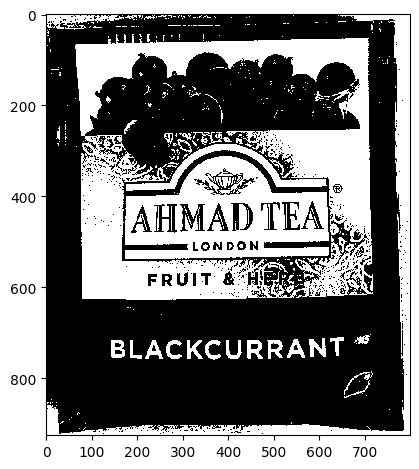

Number of labels: 1012


/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/utils.py:31: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


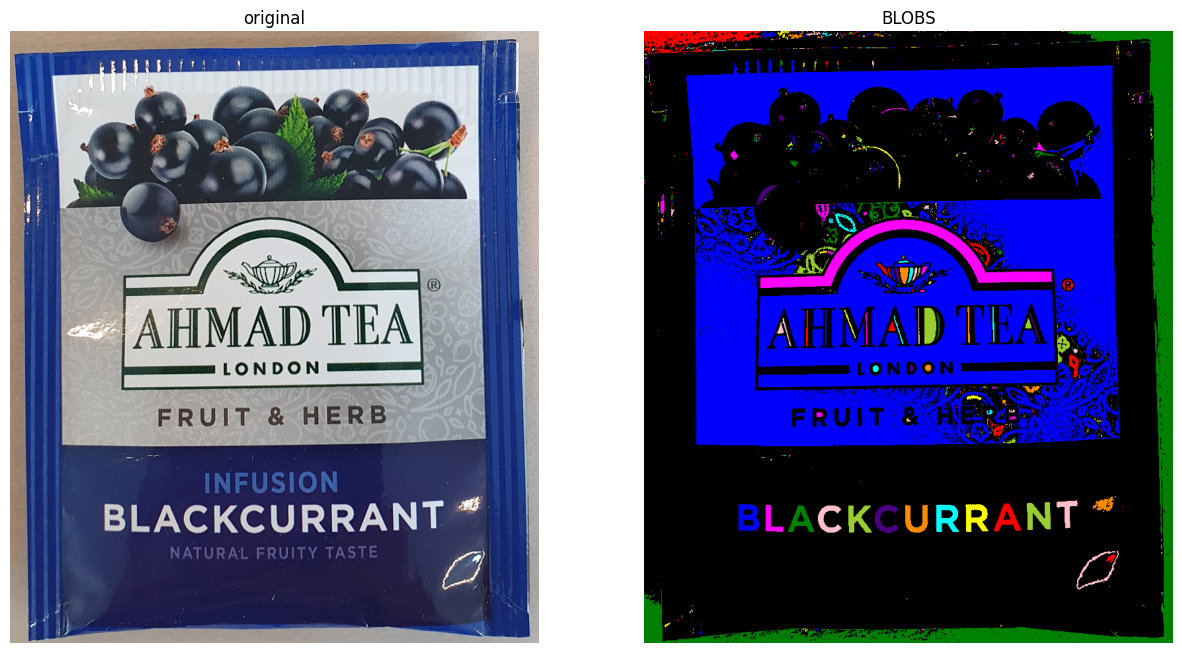

Amount of blobs for bin image 1012
Valid BLOBs remaining: 125
  Label 1 — Area: 3114.0, Perimeter: 1244.49
  Label 2 — Area: 117.0, Perimeter: 79.49
  Label 3 — Area: 76.0, Perimeter: 58.80
  Label 7 — Area: 101.0, Perimeter: 69.04
  Label 9 — Area: 60.0, Perimeter: 49.56
  Label 11 — Area: 18.0, Perimeter: 17.04
  Label 28 — Area: 37.0, Perimeter: 31.45
  Label 36 — Area: 17.0, Perimeter: 17.21
  Label 37 — Area: 32.0, Perimeter: 27.49
  Label 107 — Area: 21.0, Perimeter: 18.41
  Label 153 — Area: 41.0, Perimeter: 39.21
  Label 158 — Area: 23.0, Perimeter: 21.21
  Label 166 — Area: 38.0, Perimeter: 34.66
  Label 175 — Area: 29.0, Perimeter: 23.31
  Label 180 — Area: 25.0, Perimeter: 21.21
  Label 204 — Area: 27.0, Perimeter: 23.04
  Label 234 — Area: 55.0, Perimeter: 54.04
  Label 240 — Area: 25.0, Perimeter: 25.83
  Label 245 — Area: 34.0, Perimeter: 25.90
  Label 246 — Area: 54.0, Perimeter: 31.80
  Label 249 — Area: 20.0, Perimeter: 18.04
  Label 275 — Area: 33.0, Perimeter: 24.14


/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/utils.py:31: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


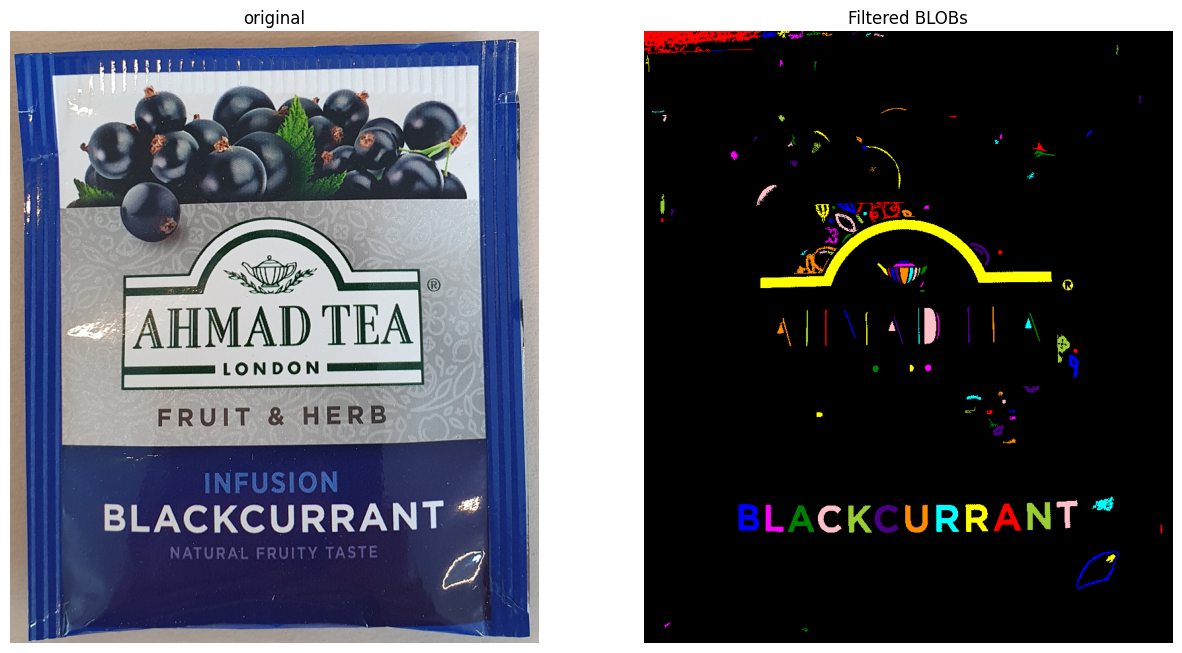

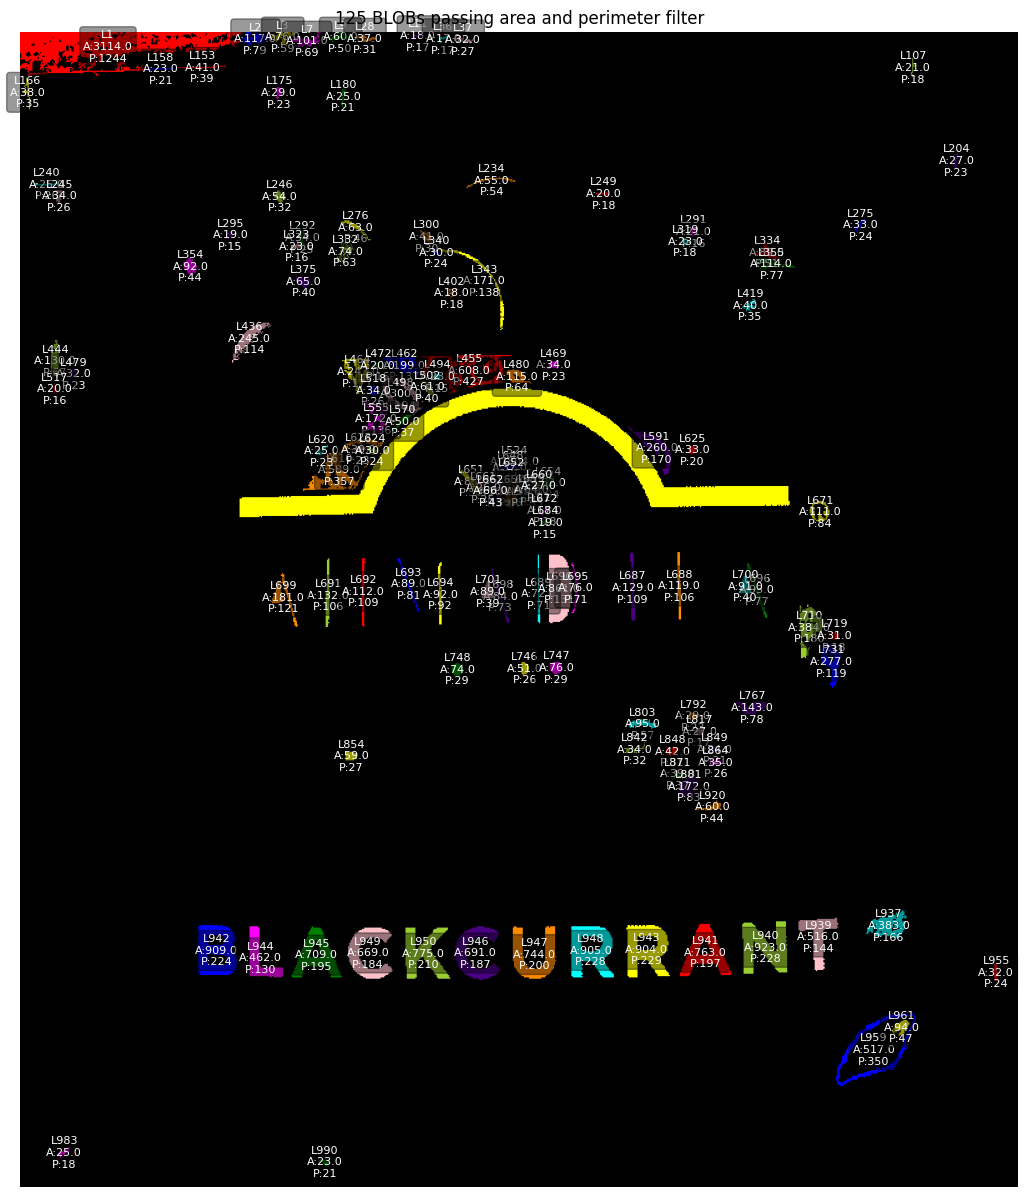

In [26]:
# Teabag

from utils import plot_comparison

path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/data/"

path = path + "tea_bags/"

img = io.imread(path + "TeaBag.png")




img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

img_gray_norm = img_gray / 255.0
T = 0.6

bin_img = img_gray_norm > T

io.imshow(bin_img)
io.show()


label_img = measure.label(bin_img)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")


im_blob = label2rgb(label_img)
plot_comparison(img, im_blob, 'BLOBS', x_dimension = 15, y_dimension = 15)

region_props = measure.regionprops(label_img)
area = np.array([prop.area for prop in region_props])
perimeter = np.array([prop.perimeter for prop in region_props])

print(f"Amount of blobs for bin image {len(region_props)}")


thresh_area_min = 0
thresh_area_max = 10000000
thresh_perim_min = 15
thresh_perim_max = 5000

# Keep full prop objects so you can access all attributes including perimeter
valid_props = [prop for prop in region_props 
               if thresh_area_min < prop.area < thresh_area_max
               and thresh_perim_min < prop.perimeter < thresh_perim_max]

print(f"Valid BLOBs remaining: {len(valid_props)}")
for prop in valid_props:
    print(f"  Label {prop.label} — Area: {prop.area}, Perimeter: {prop.perimeter:.2f}")

import matplotlib.pyplot as plt
from skimage.color import label2rgb

# Build a new label image with only valid BLOBs
clean_label_img = np.zeros_like(label_img)
for prop in valid_props:
    clean_label_img[label_img == prop.label] = prop.label

# Colour overlay of surviving BLOBs
im_blob_filtered = label2rgb(clean_label_img, bg_label=0)

plot_comparison(img, im_blob_filtered, 'Filtered BLOBs', x_dimension=15, y_dimension=15)

# Optionally annotate each surviving BLOB with its label, area and perimeter
fig, ax = plt.subplots(figsize=(15, 15))
ax.imshow(im_blob_filtered)

for prop in valid_props:
    cy, cx = prop.centroid
    ax.text(cx, cy,
            f"L{prop.label}\nA:{prop.area}\nP:{prop.perimeter:.0f}",
            color='white',
            fontsize=8,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.4))

plt.title(f'{len(valid_props)} BLOBs passing area and perimeter filter')
plt.axis('off')
plt.show()

In [ ]:

path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/data/"

path = path + "video/"

imgs = ["movie_000.jpg", "movie_001.jpg", "movie_002.jpg", "movie_003.jpg", "movie_004.jpg", "movie_005.jpg"]

import time
import cv2
import numpy as np
from skimage.util import img_as_float
from skimage.util import img_as_ubyte


def show_in_moved_window(win_name, img, x, y):
    """
    Show an image in a window, where the position of the window can be given
    """
    cv2.namedWindow(win_name)
    cv2.moveWindow(win_name, x, y)
    cv2.imshow(win_name,img)


def capture_from_camera_and_show_images(from_cam = type(bool), given_frame, alpha, T):
    print("Starting image capture")
    if from_cam == True:
        print("Opening connection to camera")
        url = 0
        use_droid_cam = False
        cap = cv2.VideoCapture(0, cv2.CAP_V4L2)

    # Force MJPG format (much more bandwidth-efficient over usbipd)
        cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        cap.set(cv2.CAP_PROP_FPS, 15)
        if use_droid_cam:
            url = "http://192.168.1.120:4747/video"
        cap = cv2.VideoCapture(url)
        # cap = cv2.VideoCapture(0)
        if not cap.isOpened():
            print("Cannot open camera")
            exit()

        print("Starting camera loop")
        # Get first image
        ret, frame = cap.read()
        # if frame is read correctly ret is True
        if not ret:
            print("Can't receive frame")
            exit()

    elif from_cam == False:
        frame = given_frame
    # Transform image to gray scale and then to float, so we can do some processing
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_gray = img_as_float(frame_gray)

    # To keep track of frames per second
    start_time = time.time()
    n_frames = 0
    stop = False
    while not stop:
        ret, new_frame = cap.read()
        if not ret:
            print("Can't receive frame. Exiting ...")
            break

        # Transform image to gray scale and then to float, so we can do some processing
        new_frame_gray = cv2.cvtColor(new_frame, cv2.COLOR_BGR2GRAY)
        new_frame_gray = img_as_float(new_frame_gray)

        # Compute difference image
        dif_img = np.abs(new_frame_gray - frame_gray)

        # Keep track of frames-per-second (FPS)
        n_frames = n_frames + 1
        elapsed_time = time.time() - start_time
        fps = int(n_frames / elapsed_time)

        # Put the FPS on the new_frame
        str_out = f"fps: {fps}"
        font = cv2.FONT_HERSHEY_COMPLEX
        cv2.putText(new_frame, str_out, (100, 100), font, 1, 255, 1)

        # Display the resulting frame
        show_in_moved_window('Input', new_frame, 0, 10)
        show_in_moved_window('Input gray', new_frame_gray, 600, 10)
        show_in_moved_window('Difference image', dif_img, 1200, 10)

        # Old frame is updated
        
        frame_gray = alpha*frame_gray+(1-alpha)*new_frame_gray
        if cv2.waitKey(1) == ord('q'):
            stop = True

    print("Stopping image loop")
    cap.release()
    cv2.destroyAllWindows()


if __name__ == '__main__':
    capture_from_camera_and_show_images()


error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


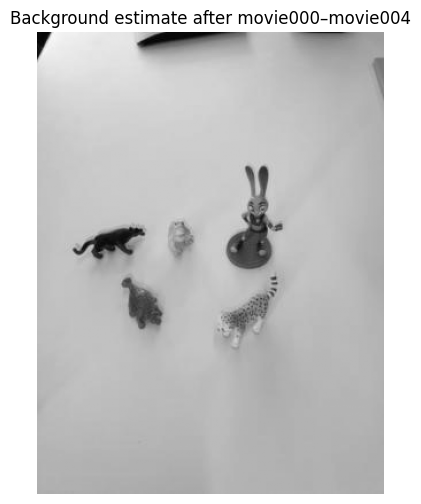

###################################################################
The max pixel value in the background image: 0.9199632244705882
###################################################################


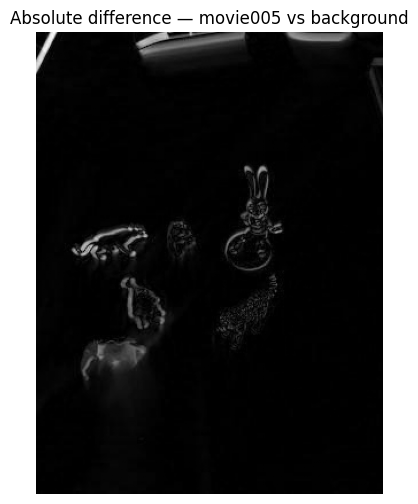

Change in binary 3274


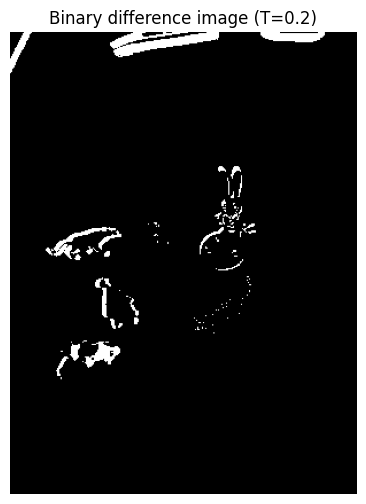

Number of connected moving objects: 98
  BLOB 1 — Area: 208.0, Centroid: (15.0, 7.4)
  BLOB 2 — Area: 992.0, Centroid: (8.3, 127.7)
  BLOB 3 — Area: 388.0, Centroid: (3.7, 245.8)
  BLOB 4 — Area: 23.0, Centroid: (119.0, 183.6)
  BLOB 5 — Area: 41.0, Centroid: (120.5, 195.4)
  BLOB 6 — Area: 27.0, Centroid: (134.7, 200.1)
  BLOB 7 — Area: 15.0, Centroid: (134.0, 189.8)
  BLOB 8 — Area: 11.0, Centroid: (142.3, 193.4)
  BLOB 9 — Area: 15.0, Centroid: (148.7, 185.3)
  BLOB 10 — Area: 3.0, Centroid: (149.3, 194.3)
  BLOB 11 — Area: 1.0, Centroid: (151.0, 187.0)
  BLOB 12 — Area: 4.0, Centroid: (152.5, 195.5)
  BLOB 13 — Area: 10.0, Centroid: (155.3, 200.3)
  BLOB 14 — Area: 3.0, Centroid: (153.0, 186.0)
  BLOB 15 — Area: 1.0, Centroid: (153.0, 198.0)
  BLOB 16 — Area: 3.0, Centroid: (155.3, 186.7)
  BLOB 17 — Area: 1.0, Centroid: (155.0, 197.0)
  BLOB 18 — Area: 15.0, Centroid: (159.5, 180.7)
  BLOB 19 — Area: 30.0, Centroid: (160.3, 193.2)
  BLOB 20 — Area: 12.0, Centroid: (165.5, 184.2)
 

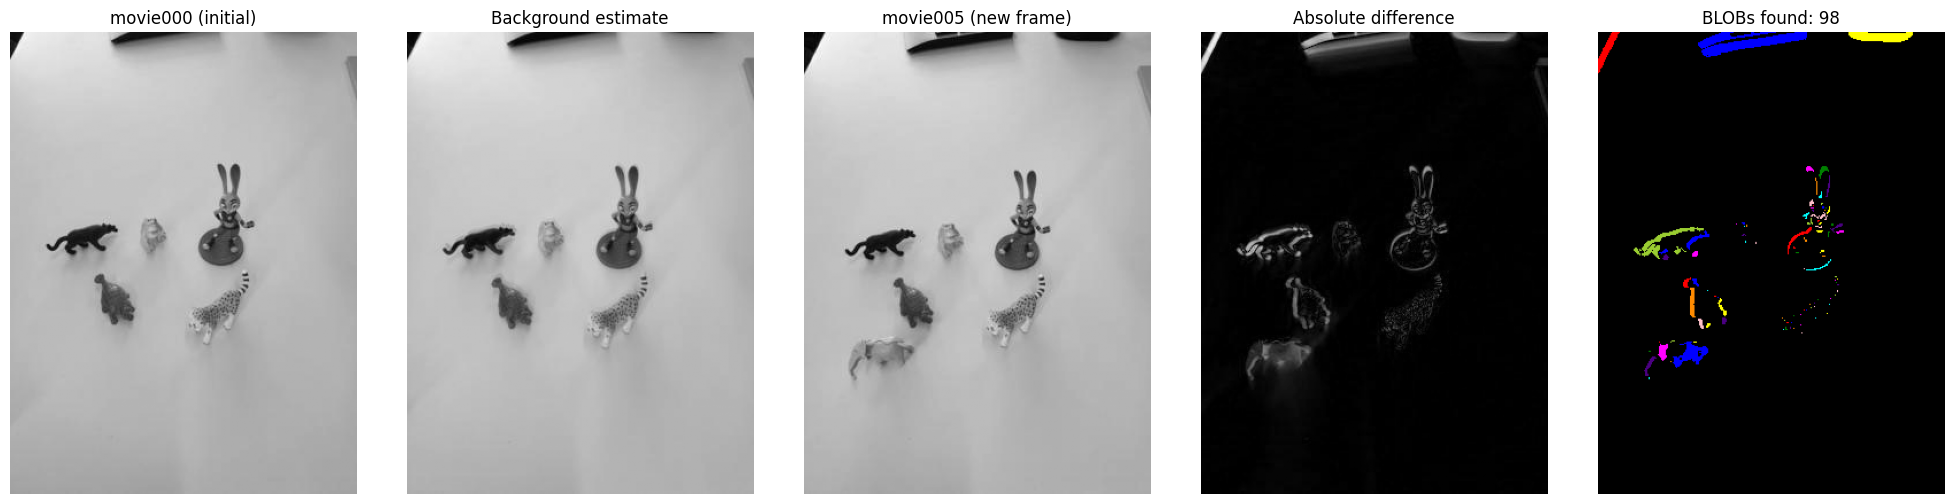

In [42]:
from skimage import io, measure, color
from skimage.color import rgb2gray, label2rgb
import numpy as np
import matplotlib.pyplot as plt

path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/data/"

path = path + "video/"
alpha = 0.8

# ── Phase 1: Initialise background with first frame ──────────────────────────
background = rgb2gray(io.imread(path + "movie_000.jpg")).astype(float)

# ── Phase 2: Update background estimate over frames 1–4 ──────────────────────
for i in range(1, 5):
    frame = rgb2gray(io.imread(path + f"movie_00{i}.jpg")).astype(float)
    background = (1 - alpha) * background + alpha * frame

# Inspect the background estimate after 5 frames
plt.figure(figsize=(6, 6))
plt.imshow(background, cmap='gray')
plt.title('Background estimate after movie000–movie004')
plt.axis('off')
plt.show()

print("###################################################################")
print(f"The max pixel value in the background image: {background.max()}")

print("###################################################################")


# ── Phase 3: Compare movie005 against the background ─────────────────────────
frame5 = rgb2gray(io.imread(path + "movie_005.jpg")).astype(float)

diff = np.abs(frame5 - background)

plt.figure(figsize=(6, 6))
plt.imshow(diff, cmap='gray')
plt.title('Absolute difference — movie005 vs background')
plt.axis('off')
plt.show()

# ── Phase 4: Threshold the difference image ───────────────────────────────────
T = 0.2
bin_img = diff > T

print(f"Change in binary {bin_img.sum()}")


plt.figure(figsize=(6, 6))
plt.imshow(bin_img, cmap='gray')
plt.title(f'Binary difference image (T={T})')
plt.axis('off')
plt.show()

# ── Phase 5: BLOB analysis to find connected moving objects ───────────────────
label_img = measure.label(bin_img)
n_labels = label_img.max()
print(f"Number of connected moving objects: {n_labels}")

region_props = measure.regionprops(label_img)
for prop in region_props:
    print(f"  BLOB {prop.label} — Area: {prop.area}, Centroid: ({prop.centroid[0]:.1f}, {prop.centroid[1]:.1f})")

# ── Visualise all steps together ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(rgb2gray(io.imread(path + "movie_000.jpg")), cmap='gray')
axes[0].set_title('movie000 (initial)')

axes[1].imshow(background, cmap='gray')
axes[1].set_title('Background estimate')

axes[2].imshow(frame5, cmap='gray')
axes[2].set_title('movie005 (new frame)')

axes[3].imshow(diff, cmap='gray')
axes[3].set_title('Absolute difference')

im_blob = label2rgb(label_img, bg_label=0)
axes[4].imshow(im_blob)
axes[4].set_title(f'BLOBs found: {n_labels}')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_484168/1651417370.py:27: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(bin_mask)
/tmp/ipykernel_484168/1651417370.py:28: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


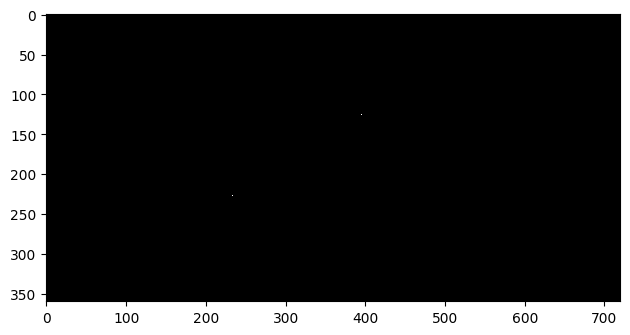

Number of marked pixels: 3
  Pixel 1: row=90, col=155
  Pixel 2: row=126, col=395
  Pixel 3: row=227, col=233
ROI_A points (x, y):
[[155.  90.]
 [395. 126.]
 [233. 227.]]

Corresponding positions in Img_B (x, y):
[[ 89.13676885  35.85861512]
 [210.43936641  32.74737335]
 [139.43917139  96.54566727]]


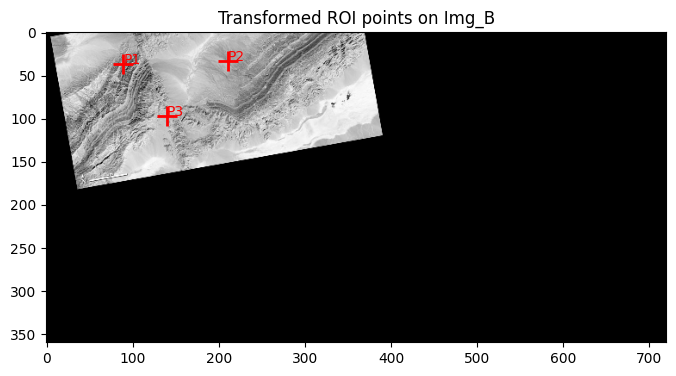

In [ ]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/data/"

path = path + "satellite/"


img = io.imread(path + "Satellite_A.png")


# obtain correct orientation 

translation_amount = [5, 5]
rotation_angle = 10 * math.pi /180
scale = 0.5
T = SimilarityTransform(translation=[5, 5])

# Clockwise rotation of 10 degrees
# NOTE: skimage uses counter-clockwise convention so clockwise = negative angle
R = SimilarityTransform(rotation=-10 * math.pi / 180)

# Scaling of 50%
S = SimilarityTransform(scale=0.5)

t_form_combined = S+R+T
img_b = warp(img, t_form_combined.inverse)
bin_mask = io.imread(path + "ROI_A.png")
bin_mask = bin_mask > 0
io.imshow(bin_mask)
io.show()

rows, cols = np.where(bin_mask)
print(f"Number of marked pixels: {len(rows)}")
for i, (r, c) in enumerate(zip(rows, cols)):
    print(f"  Pixel {i+1}: row={r}, col={c}")


# ── Step 4: Find the 3 ROI_A pixel coordinates ────────────────────────────────
roi_a = io.imread(path + "ROI_A.png")
rows, cols = np.where(roi_a > 0)

# Stack as (x, y) — note: col=x, row=y
points_a = np.column_stack([cols, rows]).astype(float)
print(f"ROI_A points (x, y):\n{points_a}")

# ── Step 5: Apply forward transform to find positions in Img_B ────────────────
points_b = matrix_transform(points_a, t_form_combined.params)
print(f"\nCorresponding positions in Img_B (x, y):\n{points_b}")

# Visualise on Img_B
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_b, cmap='gray')
ax.plot(points_b[:, 0], points_b[:, 1], 'r+', markersize=15, markeredgewidth=2)
for i, p in enumerate(points_b):
    ax.annotate(f'P{i+1}', p, color='red', fontsize=10)
ax.set_title('Transformed ROI points on Img_B')
plt.show()


from scipy.ndimage import map_coordinates

# ── Step 6: Find non-zero pixels in ROI_B ─────────────────────────────────────
roi_b = io.imread(path + "ROI_B.png")
rows_b, cols_b = np.where(roi_b > 0)
points_in_b = np.column_stack([cols_b, rows_b]).astype(float)
print(f"\nROI_B non-zero pixel positions:\n{points_in_b}")

# ── Step 7: Map ROI_B coordinates back to Satellite_A ─────────────────────────
# Apply the inverse transform to get corresponding positions in Satellite_A
points_in_a = matrix_transform(points_in_b, tform_matrix.inverse.params)
print(f"\nCorresponding positions in Satellite_A:\n{points_in_a}")

# ── Step 8: Bilinear interpolation of Satellite_A at those positions ───────────
# map_coordinates expects (row, col) = (y, x)
sampled_values = map_coordinates(
    img_a.astype(float),
    [points_in_a[:, 1], points_in_a[:, 0]],  # row=y, col=x
    order=1,        # order=1 is bilinear interpolation
    mode='constant',
    cval=0
)

print(f"\nInterpolated pixel values at ROI_B locations:")
for i, (pt, val) in enumerate(zip(points_in_b, sampled_values)):
    print(f"  ROI_B pixel {i+1} at ({pt[0]:.0f}, {pt[1]:.0f}) → interpolated value: {val:.4f}")

/tmp/ipykernel_484168/313632516.py:15: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(bin_img)


Number of connected moving objects: 8


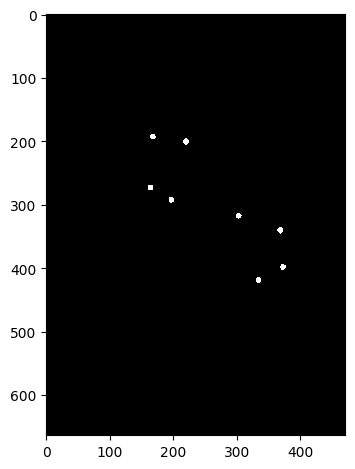

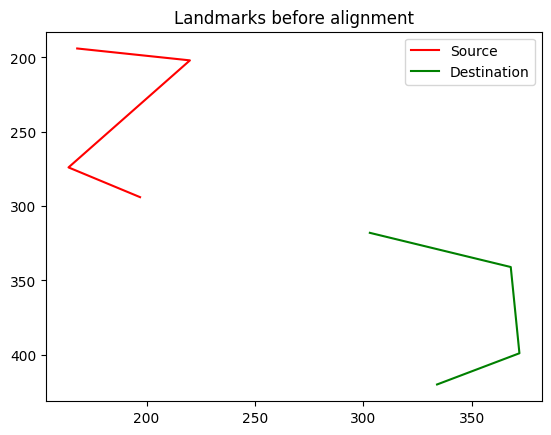

157.0
3715.0


In [58]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/data/"

path = path + "pedestrian/"

import numpy as np
src = np.array([[168, 194], [220, 202], [164, 274], [197, 294]])
dst = np.array([[303, 318], [368, 341], [372, 399], [334, 420]])


img = io.imread(path + "CarTraining_Landmarks.png")

bin_img = img > 0


io.imshow(bin_img)
io.show

label_img = measure.label(bin_img)
n_labels = label_img.max()
print(f"Number of connected moving objects: {n_labels}")




# region_props = measure.regionprops(label_img)
# for prop in region_props:

#     print(f"  BLOB {prop.label} — Area: {prop.area}, Centroid: ({prop.centroid[1]:.1f}, {prop.centroid[0]:.1f})")



# plt.imshow(src_img)
# plt.plot(src[:, 0], src[:, 1], '.r', markersize=12)
# plt.show()

# #Lx-7.10 Compute the objective function between two sets of landmarks

# %matplotlib qt 
# plt.imshow(src_img)
# plt.show()

# %matplotlib inline

# plt.close()

# dst = np.array([[621, 293], [382, 166], [198, 266], [270, 440], [600, 450]])
fig, ax = plt.subplots()
ax.plot(src[:, 0], src[:, 1], '-r', markersize=12, label="Source")
ax.plot(dst[:, 0], dst[:, 1], '-g', markersize=12, label="Destination")
ax.invert_yaxis()
ax.legend()
ax.set_title("Landmarks before alignment")
plt.show()


translation = np.mean(dst-src,axis=0)

print(abs(translation[0]))

src_translate = src + translation

ssd = np.sum((src_translate -dst)**2)

print(ssd)


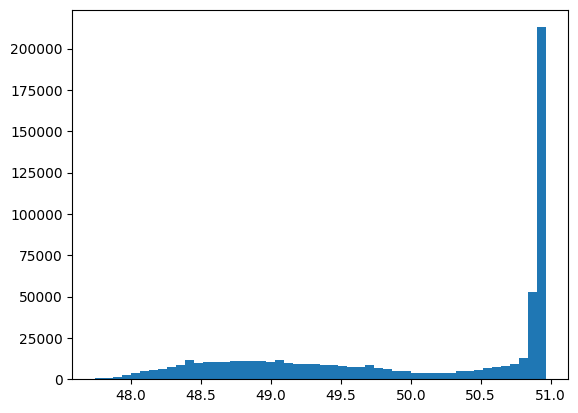

57.62850691784275


In [71]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/data/"

path = path + "animals/"



def normalize(img):
    TRANSLATION = 50
    img = io.imread(path + img)
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    img_norm = (img - np.mean(img))/np.std(img) + TRANSLATION
    return img_norm
def similarity(img_a, img_b):
    #normalize pics
    img_a_norm = normalize(img_a)
    img_b_norm = normalize(img_b)



    #select every 2nd pixel
    img1_sub = img_a_norm[::2, ::2]
    img2_sub = img_b_norm[::2, ::2]


    plt.hist(img1_sub.ravel(),bins= 50)

    plt.show()
    #flatten into 1D
    v1 = img1_sub.flatten()
    v2 = img2_sub.flatten()

    #calc NCC
    ncc = np.sum((v1 - np.mean(v1)) * (v2 - np.mean(v2))) / (
    np.sqrt(np.sum((v1 - np.mean(v1))**2) * np.sum((v2 - np.mean(v2))**2))
    )

    return ncc

img_a = "ImageA.png"

img_b = "ImageB.png"


ncc =similarity(img_a,img_b)


theta_rad = np.arccos(ncc)
theta_deg = np.degrees(theta_rad)
print(theta_deg)


/tmp/ipykernel_484168/2433226780.py:28: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(bin_img)
/home/kkristjansson/miniforge3/envs/imageanalysis/lib/python3.10/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/tmp/ipykernel_484168/2433226780.py:29: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


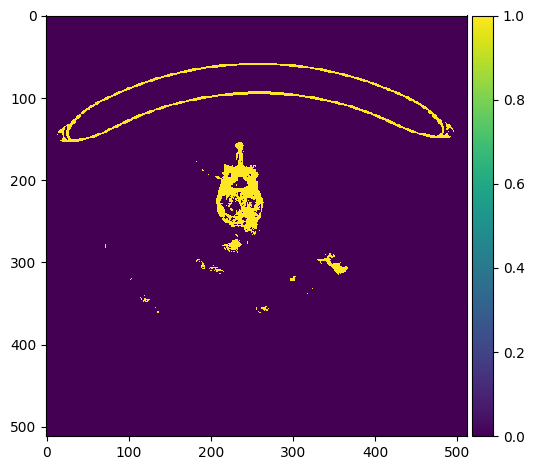

Number of connected moving objects: 19
  BLOB 1 — Area: 3280.0, Centroid: (106.0, 255.0)
  BLOB 2 — Area: 1.0, Centroid: (132.0, 326.0)
  BLOB 3 — Area: 3825.0, Centroid: (218.6, 235.5)
  BLOB 4 — Area: 2.0, Centroid: (178.0, 182.5)
  BLOB 5 — Area: 5.0, Centroid: (188.2, 190.4)
  BLOB 6 — Area: 1.0, Centroid: (193.0, 197.0)
  BLOB 7 — Area: 282.0, Centroid: (278.9, 228.4)
  BLOB 8 — Area: 1.0, Centroid: (277.0, 250.0)
  BLOB 9 — Area: 4.0, Centroid: (280.5, 72.0)
  BLOB 10 — Area: 395.0, Centroid: (302.3, 349.7)
  BLOB 11 — Area: 152.0, Centroid: (306.3, 199.1)
  BLOB 12 — Area: 26.0, Centroid: (320.6, 299.8)
  BLOB 13 — Area: 2.0, Centroid: (320.5, 102.5)
  BLOB 14 — Area: 1.0, Centroid: (332.0, 324.0)
  BLOB 15 — Area: 1.0, Centroid: (338.0, 318.0)
  BLOB 16 — Area: 52.0, Centroid: (345.1, 119.3)
  BLOB 17 — Area: 77.0, Centroid: (357.2, 262.4)
  BLOB 18 — Area: 1.0, Centroid: (355.0, 133.0)
  BLOB 19 — Area: 7.0, Centroid: (360.0, 135.4)
Valid BLOBs remaining: 1
  Label 3 — Area: 3

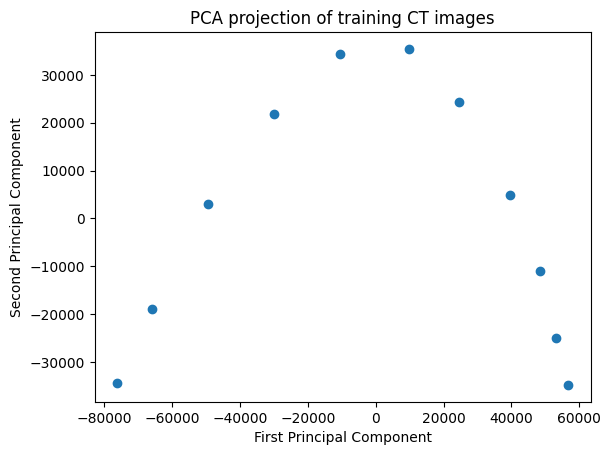

In [93]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/data/"

path = path + "chest_ct/"
training_imgs = ["1-100.dcm","1-110.dcm","1-120.dcm",
                 "1-130.dcm","1-140.dcm","1-150.dcm",
                 "1-160.dcm","1-170.dcm","1-180.dcm",
                 "1-190.dcm","1-200.dcm"]
test_imgs = ["1-105.dcm","1-115.dcm"]

images = []

for imgs in training_imgs:
    ct = dicom.dcmread(path + imgs)
    img = ct.pixel_array
    images.append(img)
# average image from training images

images = np.array(images)

avg_img = np.mean(images,axis=0)

min_fore = 100
max_fore = 500

bin_img = (avg_img > min_fore) & (avg_img < max_fore)
bin_img = bin_img.astype(np.uint8)

io.imshow(bin_img)
io.show()

close_edit = closing(bin_img, disk(5))

label_img = measure.label(close_edit)
n_labels = label_img.max()
print(f"Number of connected moving objects: {n_labels}")

region_props = measure.regionprops(label_img)
for prop in region_props:
    print(f"  BLOB {prop.label} — Area: {prop.area}, Centroid: ({prop.centroid[0]:.1f}, {prop.centroid[1]:.1f})")


thresh_area_min = 2000
thresh_area_max = 5000
thresh_perim_min = 400
thresh_perim_max = 600

# Keep full prop objects so you can access all attributes including perimeter
valid_props = [prop for prop in region_props 
               if thresh_area_min < prop.area < thresh_area_max
               and thresh_perim_min < prop.perimeter < thresh_perim_max]

print(f"Valid BLOBs remaining: {len(valid_props)}")
for prop in valid_props:
    print(f"  Label {prop.label} — Area: {prop.area}, Perimeter: {prop.perimeter:.2f}")

N,H,W = images.shape
X = images.reshape(N,H*W)

from sklearn.decomposition import PCA


pca = PCA(n_components=5)
pca.fit(X)

components = pca.components_   # (5, H*W)
scores = pca.transform(X)      # (N, 5)
pc1 = scores[:, 0]
pc2 = scores[:, 1]
plt.figure()
plt.scatter(pc1, pc2)

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA projection of training CT images")

plt.show()